# Practice notebook for univariate analysis using NHANES data

This notebook will give you the opportunity to perform some univariate analyses on your own using the NHANES data.  These analyses are similar to what was done in the week 2 NHANES case study notebook.

You can enter your code into the cells that say "enter your code here", and you can type responses to the questions into the cells that say "Type Markdown and Latex".

Note that most of the code that you will need to write below is very similar to code that appears in the case study notebook.  You will need to edit code from that notebook in small ways to adapt it to the prompts below.

To get started, we will use the same module imports and read the data in the same way as we did in the case study:

In [256]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from scipy import stats
import statsmodels.api as sm
import numpy as np

df = pd.read_csv("../../../data/raw/statistics_python/nhanes_2015_2016.csv")

## Question 1

Relabel the marital status variable [DMDMARTL](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDMARTL) to have brief but informative character labels.  Then construct a frequency table of these values for all people, then for women only and for men only.  Then construct these three frequency tables using only people whose age is between 30 and 40.

In [2]:
r = {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "NeverMarried", 6: "Cohabitating", 77: "Refused", 99: "Unknown"}
df["DMDMARTLx"] = df["DMDMARTL"].replace(r)

print("All subjects:")
x = df["DMDMARTLx"].value_counts()
print(x / x.sum())

for ky,db in df.groupby("RIAGENDR"):
    print("\nRIAGENDR=", ky)
    x = db["DMDMARTLx"].value_counts()
    print(x / x.sum())
    
df3040 = df.query('RIDAGEYR >= 30 & RIDAGEYR <= 40')
for ky,db in df3040.groupby("RIAGENDR"):
    print("\nRIAGENDR=", ky, " 30 <= RIDAGEYR <= 40")
    x = db["DMDMARTLx"].value_counts()
    print(x / x.sum())

All subjects:
DMDMARTLx
Married         0.507855
NeverMarried    0.183412
Divorced        0.105773
Cohabitating    0.096273
Widowed         0.072342
Separated       0.033979
Refused         0.000365
Name: count, dtype: float64

RIAGENDR= 1
DMDMARTLx
Married         0.562881
NeverMarried    0.184451
Cohabitating    0.100991
Divorced        0.087271
Widowed         0.038110
Separated       0.025915
Refused         0.000381
Name: count, dtype: float64

RIAGENDR= 2
DMDMARTLx
Married         0.457193
NeverMarried    0.182456
Divorced        0.122807
Widowed         0.103860
Cohabitating    0.091930
Separated       0.041404
Refused         0.000351
Name: count, dtype: float64

RIAGENDR= 1  30 <= RIDAGEYR <= 40
DMDMARTLx
Married         0.556680
NeverMarried    0.204453
Cohabitating    0.157895
Divorced        0.048583
Separated       0.024291
Widowed         0.006073
Refused         0.002024
Name: count, dtype: float64

RIAGENDR= 2  30 <= RIDAGEYR <= 40
DMDMARTLx
Married         0.535714
Nev

__Q1a.__ Briefly comment on some of the differences that you observe between the distribution of marital status between women and men, for people of all ages.

Compared to men, women have a lower probability of being currently married, a greater probability of being divorced, and a much greater probability of being widowed compared to men.

__Q1b.__ Briefly comment on the differences that you observe between the distribution of marital status states for women between the overall population, and for women between the ages of 30 and 40.

Women between the ages of 30 and 40 have a much lower probability of being widowed, a lower probability of being divorced, and a greater probability of cohabitating, compared to women of all ages.

__Q1c.__ Repeat part b for the men.

Men between the ages of 30 and 40 have a greater probability of cohabitating, a lower probability of being divorced, and a much lower probability of being widowed, compared to men of all ages.

## Question 2

Restricting to the female population, stratify the subjects into age bands no wider than ten years, and construct the distribution of marital status within each age band.  Within each age band, present the distribution in terms of proportions that must sum to 1.

In [60]:
# insert your code here
f_population = df[df['RIAGENDR'] == 2] # Subset do df para selecionar apenas mulheres
f_population.RIDAGEYR.describe()

count    2976.000000
mean       47.793011
std        18.299419
min        18.000000
25%        32.000000
50%        47.000000
75%        62.000000
max        80.000000
Name: RIDAGEYR, dtype: float64

In [ ]:
# Criando intervalos personalizados no dataset com base nos valores da var RIDAGEYR (idade)
f_population['grupo_idades'] = pd.cut(
    f_population.RIDAGEYR, [18, 20, 30, 40, 50, 60, 70, 80]
    )

# Novos labels para a var DMDMARTIL
r = {1: "Married", 2: "Widowed", 3: "Divorced", 4: "Separated", 5: "NeverMarried", 6: "Cohabitating", 77: "Refused", 99: "Unknown"}
f_population['DMDMARTL'] = f_population['DMDMARTL'].replace(r)

In [ ]:
# Agrupa por faixa etária, seleciona o status martial, conta o número de ocorrências de cada categoria
# unstack transfere os índices para nome de colunas e atribui o valor 0 para dados faltantes
marital_distribution = f_population.groupby('grupo_idades')['DMDMARTL'].value_counts().unstack(fill_value=0)
marital_distribution

DMDMARTL,Cohabitating,Divorced,Married,NeverMarried,Refused,Separated,Widowed
grupo_idades,,,,,,,
"(18, 20]",8,0,1,30,0,0,0
"(20, 30]",106,11,157,229,0,11,0
"(30, 40]",57,43,258,97,0,17,2
"(40, 50]",37,69,288,63,0,33,12
"(50, 60]",32,83,257,42,1,27,28
"(60, 70]",19,85,212,38,0,22,65
"(70, 80]",3,59,130,21,0,8,189


In [ ]:
marital_distribution_pct = marital_distribution.apply(lambda x: x/sum(x), axis = 1)

# Distribuição do estado marital em termos proporcionais 
print(marital_distribution_pct.to_string(float_format='%.3f'))

DMDMARTL      Cohabitating  Divorced  Married  NeverMarried  Refused  Separated  Widowed
grupo_idades                                                                            
(18, 20]             0.205     0.000    0.026         0.769    0.000      0.000    0.000
(20, 30]             0.206     0.021    0.305         0.446    0.000      0.021    0.000
(30, 40]             0.120     0.091    0.544         0.205    0.000      0.036    0.004
(40, 50]             0.074     0.137    0.574         0.125    0.000      0.066    0.024
(50, 60]             0.068     0.177    0.547         0.089    0.002      0.057    0.060
(60, 70]             0.043     0.193    0.481         0.086    0.000      0.050    0.147
(70, 80]             0.007     0.144    0.317         0.051    0.000      0.020    0.461


__Q2a.__ Comment on the trends that you see in this series of marginal distributions.

A proporção de mulheres divorciadas e casadas tende a aumentar com o passar das décadas, enquanto a proporção de cohabitação diminui a partir dos 30 anos. A proporção das mulheres que nunca foram casadas tende a diminuir com a idade. Quanto maior a idade, maior a chance de encontramos pessoas que são viúvas.

__Q2b.__ Repeat the analysis for males.

In [ ]:
# insert your code here
male_population = df[df['RIAGENDR'] == 1]
male_population['DMDMARTL'] = male_population['DMDMARTL'].replace(r)

In [ ]:
male_population['grupo_idades'] = pd.cut(male_population['RIDAGEYR'], [18, 20, 30, 40, 50, 60, 70, 80])

male_marital_dist = male_population.groupby('grupo_idades')['DMDMARTL'].value_counts().unstack(fill_value=0)

male_marital_dist = male_marital_dist.apply(lambda x: x/sum(x), axis=1)

In [83]:
print('Male marital distribution')
print(male_marital_dist.to_string(float_format='%.3f'))

Male marital distribution
DMDMARTL      Cohabitating  Divorced  Married  NeverMarried  Refused  Separated  Widowed
grupo_idades                                                                            
(18, 20]             0.075     0.000    0.025         0.900    0.000      0.000    0.000
(20, 30]             0.213     0.005    0.238         0.523    0.000      0.016    0.005
(30, 40]             0.157     0.052    0.563         0.194    0.002      0.026    0.004
(40, 50]             0.082     0.085    0.703         0.097    0.000      0.027    0.005
(50, 60]             0.075     0.126    0.652         0.104    0.000      0.022    0.022
(60, 70]             0.050     0.126    0.666         0.087    0.000      0.032    0.039
(70, 80]             0.022     0.142    0.612         0.022    0.000      0.035    0.167


In [84]:
print('Female marital distribution')
print(marital_distribution_pct.to_string(float_format=('%.3f')))

Female marital distribution
DMDMARTL      Cohabitating  Divorced  Married  NeverMarried  Refused  Separated  Widowed
grupo_idades                                                                            
(18, 20]             0.205     0.000    0.026         0.769    0.000      0.000    0.000
(20, 30]             0.206     0.021    0.305         0.446    0.000      0.021    0.000
(30, 40]             0.120     0.091    0.544         0.205    0.000      0.036    0.004
(40, 50]             0.074     0.137    0.574         0.125    0.000      0.066    0.024
(50, 60]             0.068     0.177    0.547         0.089    0.002      0.057    0.060
(60, 70]             0.043     0.193    0.481         0.086    0.000      0.050    0.147
(70, 80]             0.007     0.144    0.317         0.051    0.000      0.020    0.461


__Q2c.__ Comment on any notable differences that you see when comparing these results between females and for males.

A proporção de homens que cohabitam uma residência (7,5%) é muito menor do que o número de mulheres (20,5%) na mesma faixa etária (18 - 20 anos). O número de homens casados também é maior em todas as faixas de idade após os 30 anos. A porporção de indíviduos divorciados, separadas e viúvos também é menor para homens do que para mulheres. 

## Question 3

Construct a histogram of the distribution of heights using the BMXHT variable in the NHANES sample.

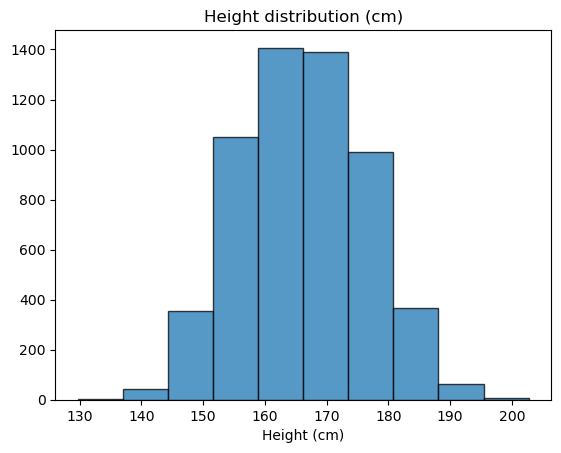

In [116]:
# insert your code here
plt.hist(df['BMXHT'], edgecolor = 'black', alpha = 0.75)
plt.title('Height distribution (cm)')
plt.xlabel('Height (cm)')
plt.show()

<Axes: xlabel='BMXHT', ylabel='Count'>

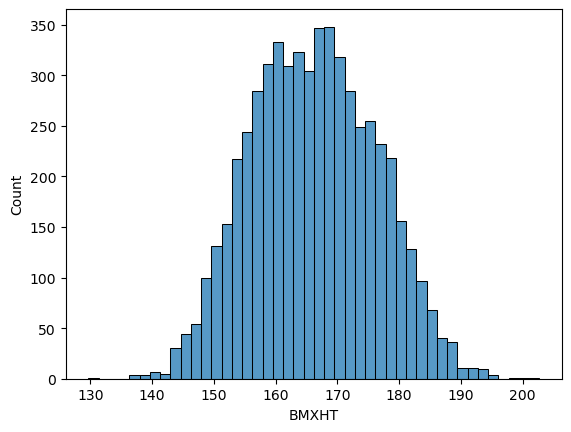

In [115]:
sns.histplot(df['BMXHT'])

__Q3a.__ Use the `bins` argument to [histplot](https://seaborn.pydata.org/generated/seaborn.histplot.html#seaborn.histplot) to produce histograms with different numbers of bins.  Assess whether the default value for this argument gives a meaningful result, and comment on what happens as the number of bins grows excessively large or excessively small. 

O valor padrão de `bins` é suficiente para observar a distribuição dos dados sem poluir a visualização com excesso de colunas e sem ocultar parte relevante do dado observado. Um número muito pequeno de `bins` torna a visualização excessivamente sintética, tornando difícil entender a real distribuição dos dados, por outro lado, muitas colunas não trazem mais informação relevante e, dependendo do número de colunas, torna difícil a visualização de clusters.

Aqui é importante notar que há diferença entre a configuração padrão de `bins` da função `histplot()` e `hist` — seaborn e pyplot, respectivamente —, o número padrão de bins é maior na função do seaborn do que na função do módulo pyplot do matplotlib.  

__Q3b.__ Make separate histograms for the heights of women and men, then make a side-by-side boxplot showing the heights of women and men.

In [41]:
# insert your code here

# dropna() logo no início do código evita problemas posteriores em boxplot
homens = df[df['RIAGENDR'] == 1]['BMXHT'].dropna()
mulheres = df[df['RIAGENDR'] == 2]['BMXHT'].dropna()

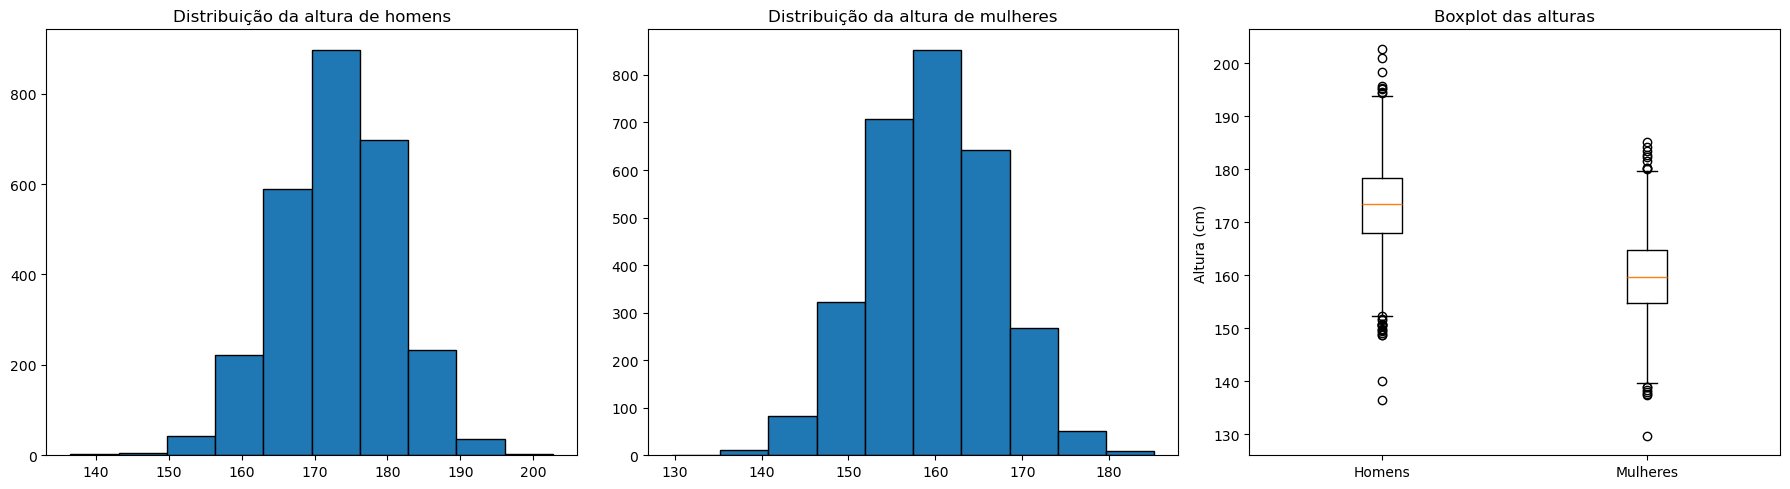

In [48]:
plt.figure(figsize= (18, 5))

# Criando o histograma das alturas
plt.subplot(1,3,1)
plt.hist(homens, edgecolor='black')
plt.title('Distribuição da altura de homens')

plt.subplot(1,3,2)
plt.hist(mulheres, edgecolor='black')
plt.title('Distribuição da altura de mulheres')

# Criando o boxplot das alturas

plt.subplot(1,3,3)
plt.boxplot([homens, mulheres], tick_labels=['Homens', 'Mulheres'])
plt.title('Boxplot das alturas')
plt.ylabel('Altura (cm)')
plt.tight_layout()
plt.show()

__Q3c.__ Comment on what features, if any are not represented clearly in the boxplots, and what features, if any, are easier to see in the boxplots than in the histograms.

No boxplot fica mais fácil de visualizar a altura mínima dos outliers e, com maior precisão, identificar outras medidas de distribuição central como mediana e IQR dos dados. 

## Question 4

Make a boxplot showing the distribution of within-subject differences between the first and second systolic blood pressure measurents ([BPXSY1](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY1) and [BPXSY2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BPX_I.htm#BPXSY2)).

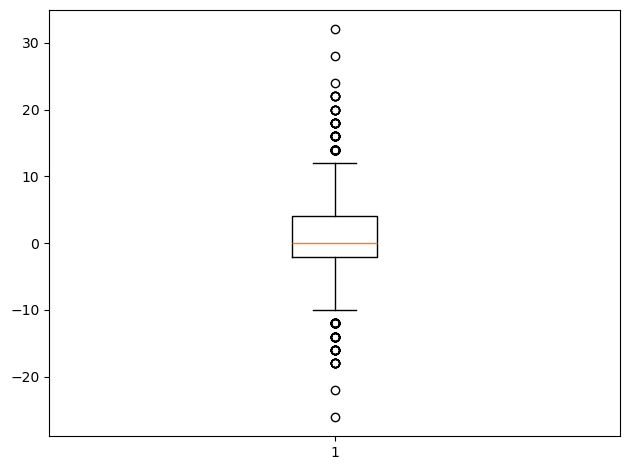

In [101]:
# insert your code here
sbp_1 = df['BPXSY1']
sbp_2 = df['BPXSY2']

systolic_diff = sbp_1 - sbp_2

plt.boxplot(systolic_diff.dropna())
plt.tight_layout()
plt.show()

__Q4a.__ What proportion of the subjects have a lower SBP on the second reading compared to the first?

In [ ]:
# Removendo valores nulos (NA) para que a comparação não seja sobre/subestimada
df_clean = df.dropna(subset=['BPXSY1', 'BPXSY2'])

sbp_1 = df_clean['BPXSY1']
sbp_2 = df_clean['BPXSY2']

# Soma quantos valores de SBP 1 são maiores que SBP 2 e divide pelo número de observações no dataset
systolic_lower_pct = (sum(sbp_2 < sbp_1) / len(df_clean)) * 100
print(f'{systolic_lower_pct:.2f}% dos indivíduos obtiveram um valor menor de SBP na segunda medição comparado a primeira')

45.87% dos indivíduos obtiveram um valor menor de SBP na segunda mediçào comparado a primeira


__Q4b.__ Make side-by-side boxplots of the two systolic blood pressure variables.

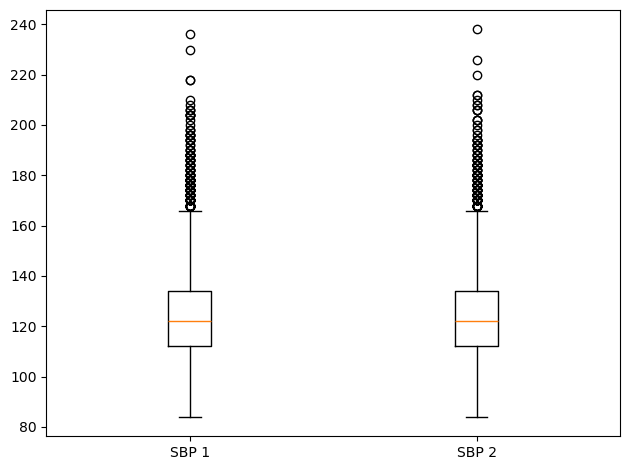

In [140]:
# insert your code here
plt.boxplot([sbp_1, sbp_2], tick_labels=['SBP 1', 'SBP 2'])
plt.tight_layout()
plt.show()

__Q4c.__ Comment on the variation within either the first or second systolic blood pressure measurements, and the variation in the within-subject differences between the first and second systolic blood pressure measurements.

Os gráficos mostram a distribuição de SBP, sendo notável o número de valores considerados 'outilers' (Q3 + 1.5 IQR). A mediana da primeira e segunda medição são praticamente as mesmas, embora sejam observados valores máximos e mínimos ligeiramente maiores na segunda medição.

## Question 5

Construct a frequency table of household sizes for people within each educational attainment category (the relevant variable is [DMDEDUC2](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#DMDEDUC2)).  Convert the frequencies to proportions.

In [310]:
# insert your code here
df["DMDEDUC2"] = df.DMDEDUC2.replace({1: "<9", 2: "9-11", 3: "HS/GED", 4: "Some college/AA", 5: "College", 
                                       7: "Refused", 9: "Don't know"})

In [307]:
household_size_educational = df.groupby('DMDHHSIZ')['DMDEDUC2'].value_counts().unstack(fill_value=0)
print('Distribuição percentual do número de pessoas habitando uma moradia (1 a 7 pessoas) de acordo com nível educacional')
hh_size_pct = household_size_educational.apply(lambda linha: (linha/sum(linha))*100, axis=0)
print(hh_size_pct.to_string(float_format='%.2f'))

Distribuição percentual do número de pessoas habitando uma moradia (1 a 7 pessoas) de acordo com nível educacional
DMDEDUC2   1.0   2.0   3.0   4.0   5.0   9.0
DMDHHSIZ                                    
1        10.99 11.66 15.26 15.11 14.28  0.00
2        22.44 22.24 27.07 26.90 34.77 66.67
3        14.66 16.33 17.12 19.31 19.40  0.00
4        13.28 15.24 16.19 16.90 16.54  0.00
5        14.81 14.62 10.96 12.21  9.52 33.33
6        10.84 11.35  6.58  5.06  2.93  0.00
7        12.98  8.55  6.83  4.50  2.56  0.00


__Q5a.__ Comment on any major differences among the distributions.

Os dados parecem indicar que quanto maior o nível educacional, há uma tendência maior do número de pessoas habitando a mesma residência ser menor. Para pessoas que completaram o college, HS/GED e Some College, 4 pessoas por habitação parece ser o teto, a partir disso o percentual cai em cada um desses grupos, sendo que no grupo de pessoas com college, moradias com 5 pessoas é quase 50% menor do que com 4 pessoas. Dentre aqueles que completaram até 11th grande e menos que 9th grade, é relativamente comum haver moradias com mais de 4 pessoas. 

__Q5b.__ Restrict the sample to people between 30 and 40 years of age.  Then calculate the median household size for women and men within each level of educational attainment.

In [311]:
# insert your code here
dx = df[(df['RIDAGEYR'] > 30) & (df['RIDAGEYR'] < 40)]

dx['RIAGENDR'] = dx['RIAGENDR'].replace({1: "Male", 2: "Female"})

dx.groupby(['RIAGENDR', 'DMDEDUC2'])['DMDHHSIZ'].median()

RIAGENDR  DMDEDUC2       
Female    9-11               5.0
          <9                 5.0
          College            4.0
          HS/GED             5.0
          Some college/AA    4.0
Male      9-11               5.0
          <9                 5.0
          College            3.0
          HS/GED             4.0
          Some college/AA    4.0
Name: DMDHHSIZ, dtype: float64

## Question 6

The participants can be clustered into "masked variance units" (MVU) based on every combination of the variables [SDMVSTRA](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVSTRA) and [SDMVPSU](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#SDMVPSU).  Calculate the mean age ([RIDAGEYR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIDAGEYR)), height ([BMXHT](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXHT)), and BMI ([BMXBMI](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/BMX_I.htm#BMXBMI)) for each gender ([RIAGENDR](https://wwwn.cdc.gov/Nchs/Nhanes/2015-2016/DEMO_I.htm#RIAGENDR)), within each MVU, and report the ratio between the largest and smallest mean (e.g. for height) across the MVUs.

In [196]:
len(df['SDMVSTRA'].unique())

15

In [258]:
# insert your code here
df['RIAGENDR'] = df['RIAGENDR'].replace({1: 'Male', 2: 'Female'})
df_mvu = df.groupby(['SDMVPSU', 'SDMVSTRA', 'RIAGENDR'])[['RIDAGEYR', 'BMXHT', 'BMXBMI']].mean()
print(df_mvu.unstack().to_string(float_format='%.2f'))

                 RIDAGEYR        BMXHT        BMXBMI      
RIAGENDR           Female  Male Female   Male Female  Male
SDMVPSU SDMVSTRA                                          
1       119         47.66 47.86 159.57 172.74  30.05 26.96
        120         43.64 43.13 155.40 169.54  32.42 30.94
        121         44.40 46.75 158.87 172.18  30.86 29.42
        122         42.90 44.65 161.32 174.00  29.45 28.53
        123         44.84 47.83 162.06 174.32  29.91 29.23
        124         51.66 50.75 158.79 172.11  29.53 28.61
        125         50.90 55.17 160.76 173.63  30.39 29.73
        126         46.23 48.42 160.39 175.15  31.26 29.03
        127         49.69 53.14 157.42 171.55  32.19 31.06
        128         55.64 53.67 156.34 169.32  32.30 31.75
        129         45.33 43.92 156.90 171.09  29.02 26.49
        130         47.81 50.52 161.98 176.97  30.70 30.34
        131         54.89 53.14 161.99 175.61  30.06 28.26
        132         43.21 42.38 161.51 172.53  29.85 28.

In [301]:
media_SPU_1 = df_mvu.xs(1, level='SDMVPSU')
media_SPU_2 = df_mvu.xs(2, level='SDMVPSU')

ratio_SPU_1 = media_SPU_1.max()/media_SPU_1.min()
ratio_SPU_2 = media_SPU_2.max()/media_SPU_2.min()

print(f"Ratio SPU 1:\n{ratio_SPU_1}")
print(f"\nRatio SPU 2:\n{ratio_SPU_2}")

Ratio SPU 1:
RIDAGEYR    1.312834
BMXHT       1.138815
BMXBMI      1.223688
dtype: float64

Ratio SPU 2:
RIDAGEYR    1.292429
BMXHT       1.113592
BMXBMI      1.281213
dtype: float64


__Q6a.__ Comment on the extent to which mean age, height, and BMI vary among the MVUs.

A média de idade entre os grupos SPU 1 e 2 varia, respectivamente, 31% e 29% dentro do mesmo grupo em relação a menor média. A variação de altura dentro dos grupos é menor, 13,8% contra 11,3%, e, por fim, o BMI varia 22% e 28%. Os grupos possuem variação semelhante no quesito altura e idade, com uma discrepância um pouco maior no BMI, indicando que para essa variável os grupos sejam mais heterogêneos.

__Q6b.__ Calculate the inter-quartile range (IQR) for age, height, and BMI for each gender and each MVU.  Report the ratio between the largest and smalles IQR across the MVUs.

In [302]:
# insert your code here
df_6b = df[['SDMVSTRA', 'SDMVPSU', 'RIAGENDR', 'RIDAGEYR', 'BMXHT', 'BMXBMI']]

In [305]:
g = df_6b.groupby(['SDMVPSU', 'SDMVSTRA', 'RIAGENDR'])

iqr = g.quantile(0.75) - g.quantile(0.25)
# print(iqr.unstack().to_string(float_format='%.2f'))
ratio_iqr = iqr.max() / iqr.min()
ratio_iqr

RIDAGEYR    1.831325
BMXHT       1.623762
BMXBMI      2.865854
dtype: float64

__Q6c.__ Comment on the extent to which the IQR for age, height, and BMI vary among the MVUs.

Para idade, o ratio do IQR é ~1,83; para altura, ~1,62; para BMI, ~2,86, indicando que a dispersão de BMI varia mais entre os MVUs do que a de altura e idade.